# Shear response to parameter

Use the emulator to see how shear signal from ridges change with parameters. We can't study this directly from the original simulations as all paramters vary at the same time in CosmoGRID.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

# %ls
%cd ../

import predict
import load_data

%cd ../

/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu


I0000 00:00:1788530138.140683  796956 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788530138.141059  796956 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788530138.175032  796956 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788530139.159989  796956 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

/home/s2561233/Documents/lss/ridges/ridges_toolkit


In [2]:
N = 6

mycolors = ["#940014", "#FF7083", "#18698F", "#99D4E5", "#7AC011", "#FFDD03"]

from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
my_blues = LinearSegmentedColormap.from_list("", ["#18698F","#7AC011"])
norm = Normalize(vmin=0, vmax=N-1)
sm = ScalarMappable(cmap=my_blues, norm=norm)
sm.set_array([])

from matplotlib import rc
rc('text', usetex=False)
# rc('font',**{'family':'serif','serif':['Times']})

In [3]:
%cd /home/s2561233/Documents/lss/ridges/ridges_toolkit

# get radial bins, mean and stdev from metadata
with open('emu/data/metadata.json', 'r') as f:
    metadata = json.load(f)

sep_bin_center = metadata['sep_bin_center']

# choose two simulations indices to plot against prediction
idx1 = 0
idx2 = 50

all_pairs = metadata["bin_pairs"]

/home/s2561233/Documents/lss/ridges/ridges_toolkit


In [ ]:
ranges = {
    'Omega_m': {'low': 0.15,  'upp': 0.45},
    'sigma8':  {'low': 0.5,   'upp': 1.3},
    'w0':      {'low': -1.25, 'upp': -0.75},
    'n_s':     {'low': 0.93,  'upp': 1.},
    'Omega_b': {'low': 0.04,  'upp': 0.05},
    'H0':      {'low': 65.,   'upp': 75.},
    'bary_Mc': {'low': 1e12,  'upp': 1e15},
    'bary_nu': {'low': -2.,    'upp': 2.}
}

fiducials = {
    'Omega_m': 0.31,
    'bary_Mc': 13.82,
    'bary_nu': 0.,
    'sigma8': 0.83,
    'w0': -1.,
    'n_s': 0.97,
    'Omega_b': 0.05,
    'H0': 68.0,
}

param_labels = {
    'Omega_m': r'$\Omega_{\rm m}$',
    'sigma8': r'$\sigma_8$',
    'w0': r'$w_0$',
    'n_s': r'$n_{\rm s}$',
    'Omega_b': r'$\Omega_{\rm b}$',
    'H0': r'$H_0$',
    'bary_Mc': r'M$_{\rm C}$',
    'bary_nu': r'$\eta$'
}

bin_l = 0
bin_s = 3

1/1 - 0s - 48ms/step


E0000 00:00:1788530139.809079  796956 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


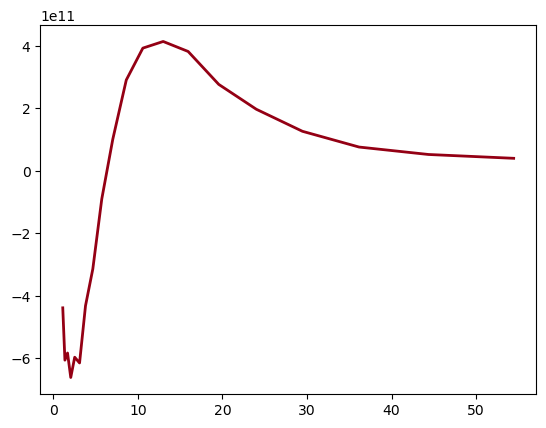

In [5]:
# plot single prediciton with fiducials
X_test, Y_test, shape_noise = load_data.load_dataset(bin_l, bin_s)

# build dictionary from X_test[0] values
x_dict = {param: X_test[0, i] for i, param in enumerate(fiducials.keys())}

prediction = predict.make_prediction(x_dict, bin_l, bin_s)

plt.plot(sep_bin_center, prediction[0], color=mycolors[0], label='Prediction', linewidth=2)

In [6]:
print(X_test[0])

[ 2.65654029e+14  8.14453125e-01  7.96708984e+01  4.62744141e-02
  4.43945313e-01  9.49199219e-01  7.30566406e-01 -9.83357910e-01]


1/1 - 0s - 35ms/step


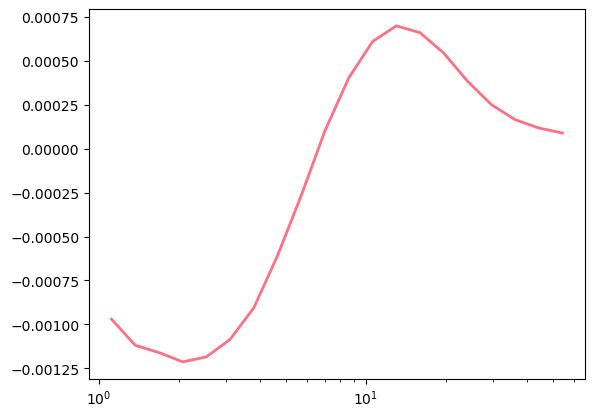

In [11]:
fiducials = {
    'Omega_m': 0.31,
    'bary_Mc': 13.82,
    'bary_nu': 0.,
    'sigma8': 0.83,
    'w0': -1.,
    'n_s': 0.97,
    'Omega_b': 0.05,
    'H0': 68.0,
}
# fiducials={
#     'Omega_m': 2.65654029e+14,
#     'bary_Mc': 8.14453125e-01,
#     'bary_nu': 7.96708984e+01,
#     'sigma8': 4.62744141e-02,
#     'w0': 4.43945313e-01,
#     'n_s': 9.49199219e-01,
#     'Omega_b': 7.30566406e-01,
#     'H0': 9.83357910e-01,
# }
prediction = predict.make_prediction(fiducials, bin_l, bin_s)
plt.plot(sep_bin_center, prediction[0], color=mycolors[1], label='Prediction', linewidth=2)
plt.xscale('log')

1/1 - 0s - 36ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 45ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 44ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 42ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 40ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 47ms/step
1/1 - 0s - 48ms/step
1/1 - 0s - 44ms/step
1/1 - 0s - 42ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 40ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 34ms/step
1/1 - 0s - 34

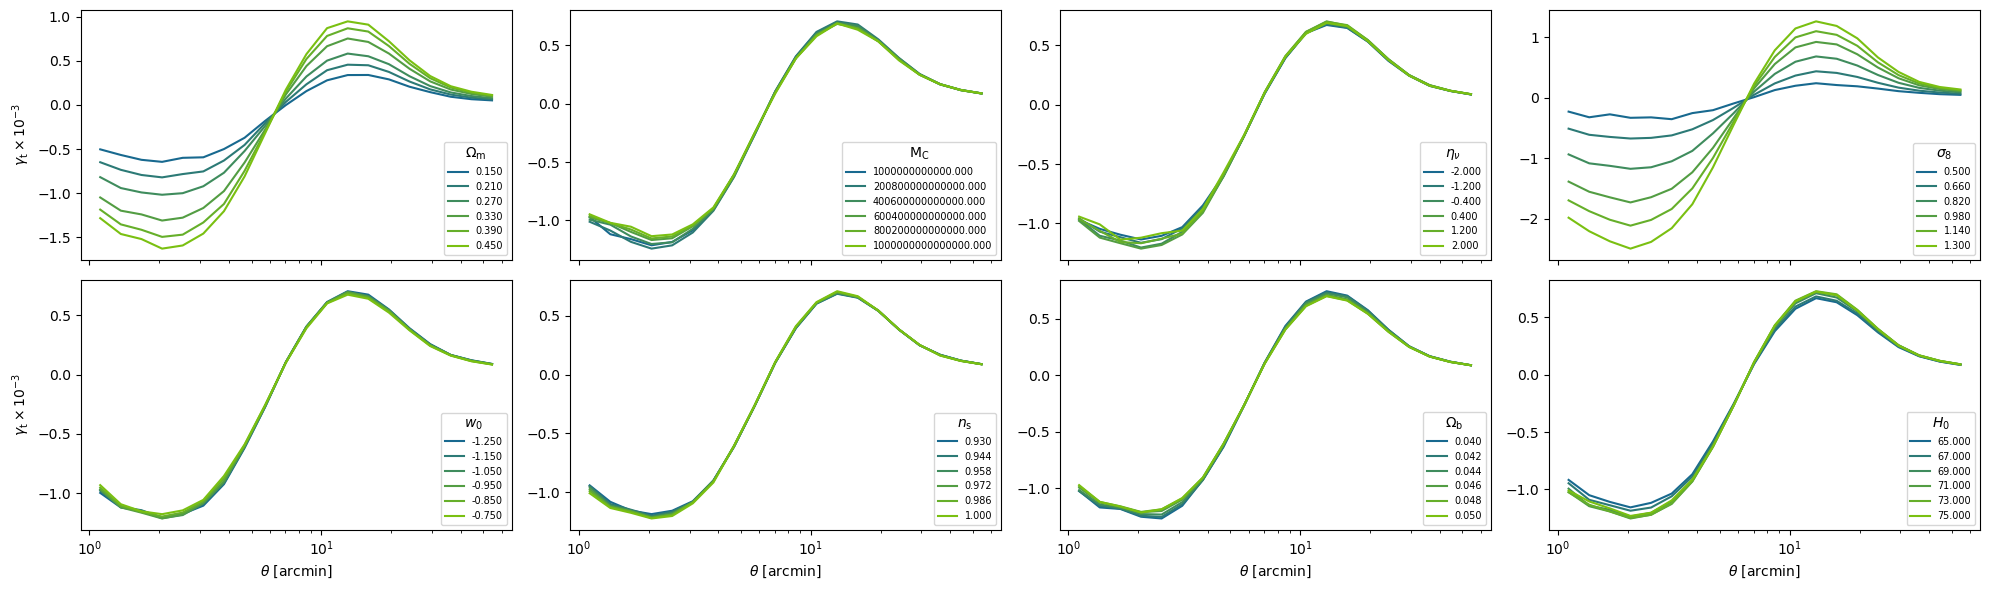

In [16]:
param_dict = fiducials.copy()

nparams = len(fiducials)
fig, axes = plt.subplots(2, 4, figsize=(20, 6), sharex=True)
axes = axes.ravel()

for ax, par in zip(axes, fiducials.keys()):
    par_arr = np.linspace(ranges[par]['low'], ranges[par]['upp'], N)

    for i, value in enumerate(par_arr):
        param_dict[par] = value

        model_path = f'emu/models/lens{bin_l}_source{bin_s}.keras'
        prediction = predict.make_prediction(param_dict, bin_l, bin_s, model_path)

        ax.plot(
            sep_bin_center,
            prediction[0]*1e3,
            color=sm.to_rgba(i),
            label=f'{value:.3f}'
            )

    param_dict[par] = fiducials[par]
    ax.legend(fontsize=7, title=param_labels[par], loc='lower right')
    # ax.set_yscale('log')
    ax.set_xscale('log')

axes[0].set_ylabel(r'$\gamma_{\rm t}\times 10^{-3}$')
axes[4].set_ylabel(r'$\gamma_{\rm t}\times 10^{-3}$')

for ax in axes[-4:]:
    ax.set_xlabel(r'$\theta$ [arcmin]')

fig.tight_layout()

- $M_C$ --> lower shear signal at higher values of Mc as more feedback redistributes more DM (i.e. less powerful lens effect)? Signal changes more at small scales, as expected.

- $\eta$ --> ??

- $\Omega_m$ and $\sigma_8$ --> higher value means more lensing, i.e. more signal
